In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('../data/index_1.csv')
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   str    
 1   datetime     3636 non-null   str    
 2   cash_type    3636 non-null   str    
 3   card         3547 non-null   str    
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   str    
dtypes: float64(1), str(5)
memory usage: 405.1 KB


In [16]:
df_null = df[df.isna().any(axis=1)]
df_null.head(30)

,date,datetime,cash_type,card,money,coffee_name
12,2024-03-02,2024-03-02 10:30:35.668,cash,NaN,40.0,Latte
18,2024-03-03,2024-03-03 10:10:43.981,cash,NaN,40.0,Latte
41,2024-03-06,2024-03-06 12:30:27.089,cash,NaN,35.0,Americano with Milk
46,2024-03-07,2024-03-07 10:08:58.945,cash,NaN,40.0,Latte
49,2024-03-07,2024-03-07 11:25:43.977,cash,NaN,40.0,Latte
60,2024-03-09,2024-03-09 11:49:37.292,cash,NaN,40.0,Hot Chocolate
74,2024-03-10,2024-03-10 07:44:18.538,cash,NaN,30.0,Americano
75,2024-03-10,2024-03-10 07:45:29.441,cash,NaN,35.0,Americano with Milk
76,2024-03-10,2024-03-10 10:06:02.960,cash,NaN,40.0,Latte
78,2024-03-10,2024-03-10 17:51:03.048,cash,NaN,35.0,Americano with Milk


In [19]:
print(f'Всего строк с null: {len(df_null)} из них с оплатой cash:{len(df_null[df_null['cash_type']=='cash'])}')

Всего строк с null: 89 из них с оплатой cash:89


(array([19783., 19844., 19905., 19967., 20028., 20089., 20148.]),
 [Text(19783.0, 0, '2024-03'),
  Text(19844.0, 0, '2024-05'),
  Text(19905.0, 0, '2024-07'),
  Text(19967.0, 0, '2024-09'),
  Text(20028.0, 0, '2024-11'),
  Text(20089.0, 0, '2025-01'),
  Text(20148.0, 0, '2025-03')])

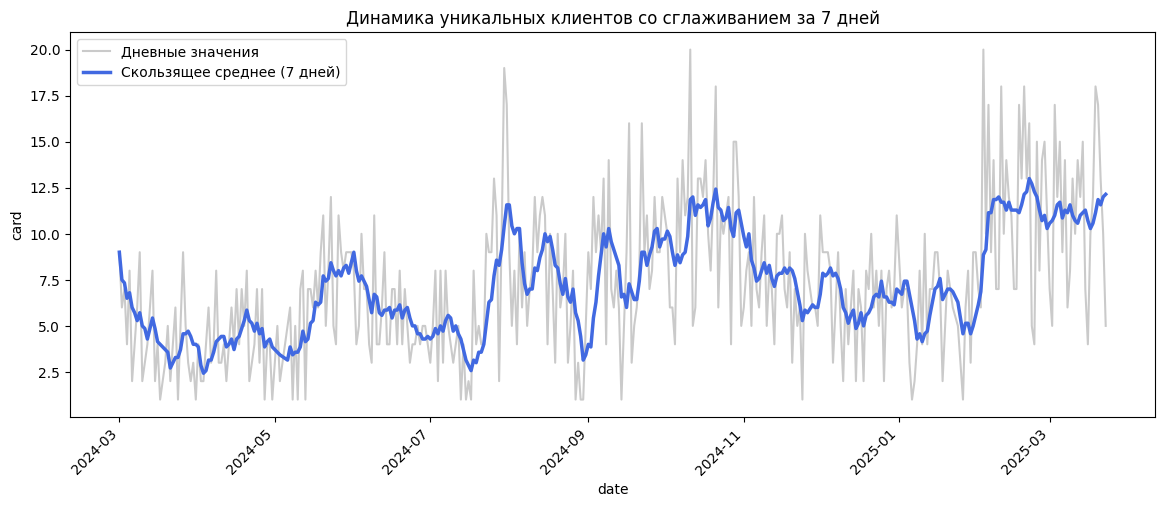

In [14]:
daily_activity=df.groupby('date').nunique().reset_index()
daily_activity['date']=pd.to_datetime(daily_activity['date'])

daily_activity['rolling_7d']=daily_activity['card'].rolling(window=7,min_periods=1).mean()

plt.figure(figsize=(14,5))
sns.lineplot(data=daily_activity, x='date',y='card',label='Дневные значения', color='gray', alpha=0.41)
sns.lineplot(data=daily_activity, x='date',y='rolling_7d',label='Скользящее среднее (7 дней)', color='royalblue', linewidth=2.5)

plt.title("Динамика уникальных клиентов со сглаживанием за 7 дней")
plt.xticks(rotation=45,ha='right')

(array([19783., 19844., 19905., 19967., 20028., 20089., 20148.]),
 [Text(19783.0, 0, '2024-03'),
  Text(19844.0, 0, '2024-05'),
  Text(19905.0, 0, '2024-07'),
  Text(19967.0, 0, '2024-09'),
  Text(20028.0, 0, '2024-11'),
  Text(20089.0, 0, '2025-01'),
  Text(20148.0, 0, '2025-03')])

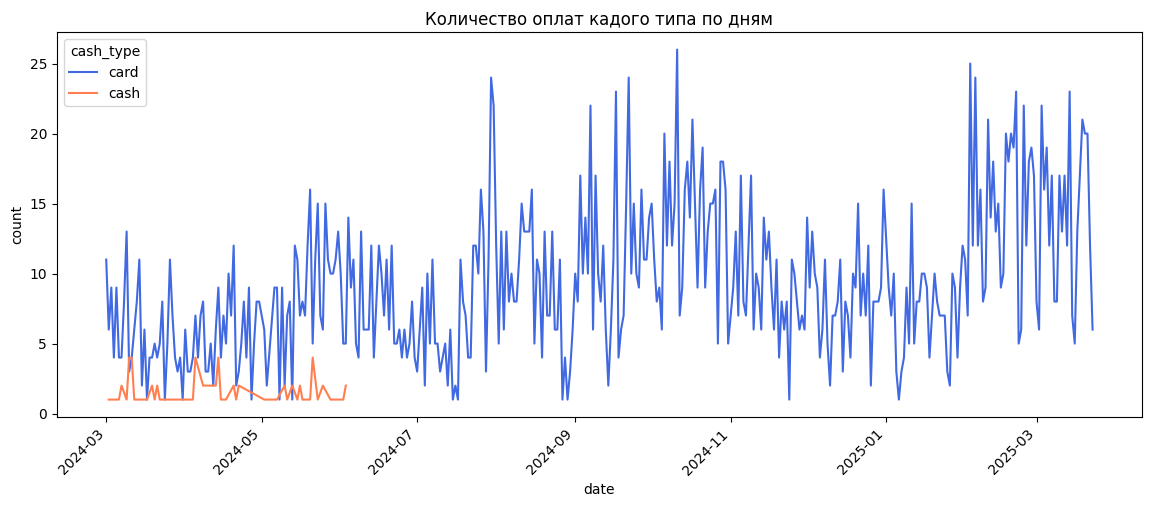

In [20]:
payments_daily=df.groupby(['date','cash_type']).size().reset_index(name='count')
payments_daily['date']=pd.to_datetime(payments_daily['date'])

plt.figure(figsize=(14,5))
sns.lineplot(data=payments_daily,x='date',y='count',hue='cash_type',palette=['royalblue','coral'])

plt.title('Количество оплат кадого типа по дням')
plt.xticks(rotation=45, ha='right')

(array([19783., 19797., 19814., 19828., 19844., 19858., 19875., 19889.,
        19905.]),
 [Text(19783.0, 0, '2024-03-01'),
  Text(19797.0, 0, '2024-03-15'),
  Text(19814.0, 0, '2024-04-01'),
  Text(19828.0, 0, '2024-04-15'),
  Text(19844.0, 0, '2024-05-01'),
  Text(19858.0, 0, '2024-05-15'),
  Text(19875.0, 0, '2024-06-01'),
  Text(19889.0, 0, '2024-06-15'),
  Text(19905.0, 0, '2024-07-01')])

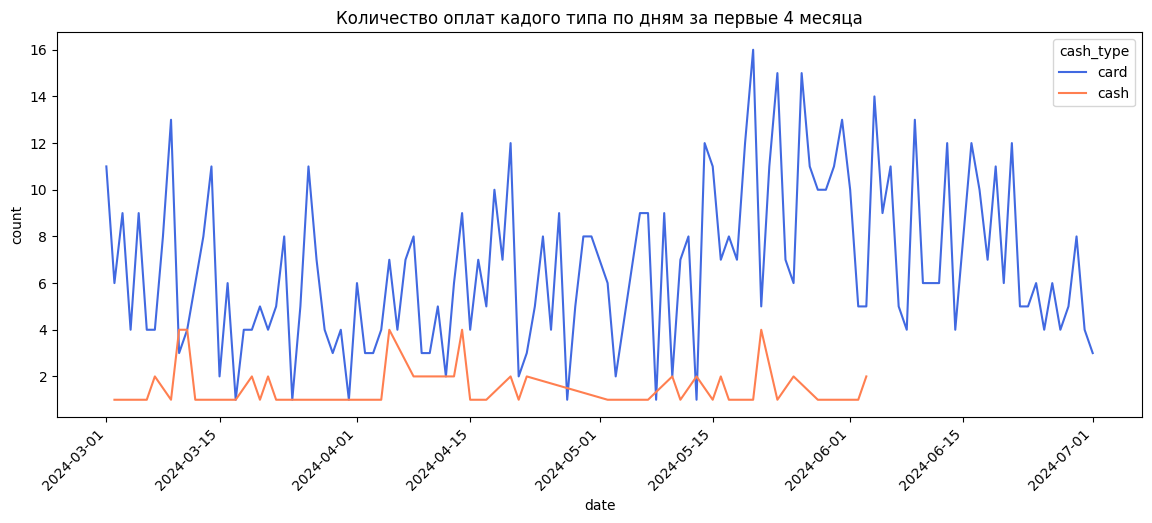

In [21]:
payments_daily_4m=payments_daily[payments_daily['date']<='2024-07-01']
plt.figure(figsize=(14,5))
sns.lineplot(data=payments_daily_4m,x='date',y='count',hue='cash_type',palette=['royalblue','coral'])

plt.title('Количество оплат кадого типа по дням за первые 4 месяца')
plt.xticks(rotation=45, ha='right')